#Set-up all reqirerments :

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Student_Performance_Prediction_System/Dataset/students_performance.csv")
#dataset is already scaled up  and in numeric form .
#i imported this real dataset through kaggle.
# it has 1000 of rows and scaled up data betweeb 0 to 1.
df

,Attendance,Assignment_Score,Midterm_Score,Final_Score,Class_Participation,Behavioral_Score,Project_Score,Study_Hours_Per_Week,Extracurricular_Score,Performance_Level
0,0.624724,0.483194,0.770892,0.630000,0.657597,0.696818,0.788954,0.266620,0.038799,Medium
1,0.970429,0.472885,0.857677,0.812262,0.844346,0.736718,0.503432,0.587711,0.186773,High
2,0.839196,0.934378,0.475328,0.638266,0.808129,0.927274,0.923437,0.885651,0.831246,Medium
3,0.759195,0.474682,0.737412,0.750624,0.323120,0.670002,0.767870,0.759002,0.766768,High
4,0.493611,0.490365,0.700222,0.599472,0.319400,0.934825,0.494322,0.825905,0.350643,Medium
...,...,...,...,...,...,...,...,...,...,...
995,0.454949,0.905707,0.609475,0.598040,0.917918,0.842218,0.747842,0.691260,0.273160,Medium
996,0.950388,0.410091,0.534081,0.677264,0.295505,0.751610,0.800222,0.960953,0.209519,Medium
997,0.482091,0.516852,0.576201,0.516825,0.462274,0.882574,0.946946,0.162062,0.455329,Medium
998,0.970142,0.503032,0.670958,0.556952,0.852596,0.742645,0.607372,0.151349,0.908438,Medium


In [3]:
# Check the total number of rows and columns
print("Dataset Shape:", df.shape)

# Check the data types and look for missing values generally
print("\n--- Dataset Information ---")
df.info()

# Count the exact number of missing (null) values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicate rows
print("\n--- Duplicate Rows ---")
print("Total duplicates:", df.duplicated().sum())

# View basic statistics (like average, minimum, and maximum values)
print("\n--- Summary Statistics ---")
display(df.describe())

Dataset Shape: (1000, 10)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Attendance             1000 non-null   float64
 1   Assignment_Score       1000 non-null   float64
 2   Midterm_Score          1000 non-null   float64
 3   Final_Score            1000 non-null   float64
 4   Class_Participation    1000 non-null   float64
 5   Behavioral_Score       1000 non-null   float64
 6   Project_Score          1000 non-null   float64
 7   Study_Hours_Per_Week   1000 non-null   float64
 8   Extracurricular_Score  1000 non-null   float64
 9   Performance_Level      1000 non-null   object 
dtypes: float64(9), object(1)
memory usage: 78.3+ KB

--- Missing Values ---
Attendance               0
Assignment_Score         0
Midterm_Score            0
Final_Score              0
Class_Participation      0
Beh

,Attendance,Assignment_Score,Midterm_Score,Final_Score,Class_Participation,Behavioral_Score,Project_Score,Study_Hours_Per_Week,Extracurricular_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.694154,0.651684,0.643263,0.631258,0.595284,0.749232,0.695985,0.556316,0.482371
std,0.175282,0.203472,0.200543,0.118520,0.229448,0.144597,0.173840,0.262971,0.284914
min,0.402779,0.300008,0.300457,0.274748,0.200025,0.503092,0.400857,0.102896,0.000241
25%,0.541584,0.482946,0.469331,0.544249,0.395979,0.624690,0.544133,0.316967,0.235989
50%,0.698084,0.650430,0.638995,0.633488,0.595678,0.745201,0.690786,0.566861,0.483991
75%,0.846592,0.831372,0.816279,0.718757,0.791995,0.869926,0.853879,0.784419,0.714466
max,0.999831,0.998475,0.999690,0.950605,0.998200,0.999675,0.999676,0.999472,0.998905


#Clean and Preprocess the Data :

In [4]:
# Drop the 'Performance_Level' column to prevent data leakage
df = df.drop(columns=['Performance_Level'])

print("New Dataset Shape:", df.shape)

# Print the remaining columns to confirm
print("\nRemaining Columns:")
print(df.columns.tolist())

New Dataset Shape: (1000, 9)

Remaining Columns:
['Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score', 'Class_Participation', 'Behavioral_Score', 'Project_Score', 'Study_Hours_Per_Week', 'Extracurricular_Score']


#Exploratory Data Analysis :

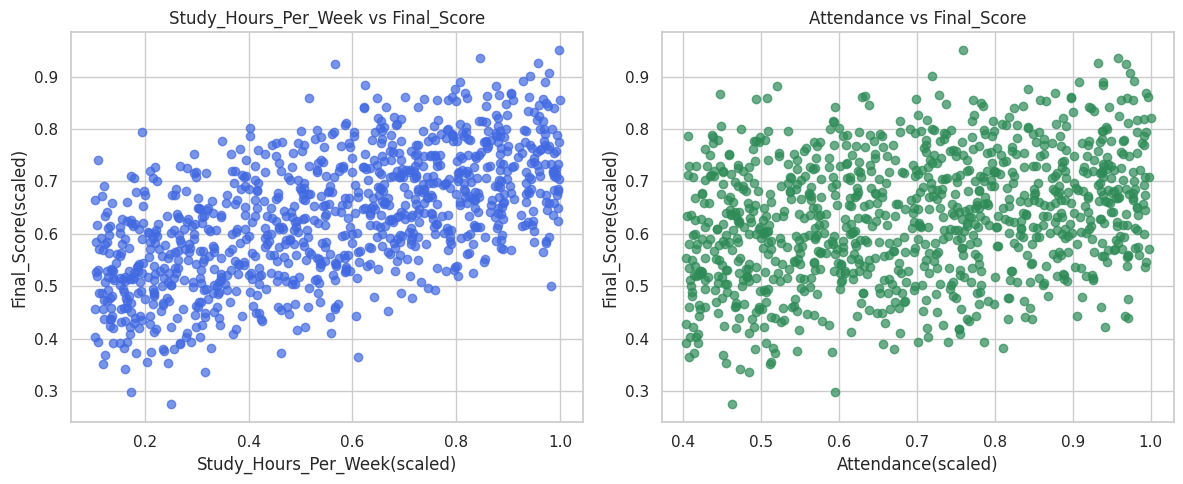

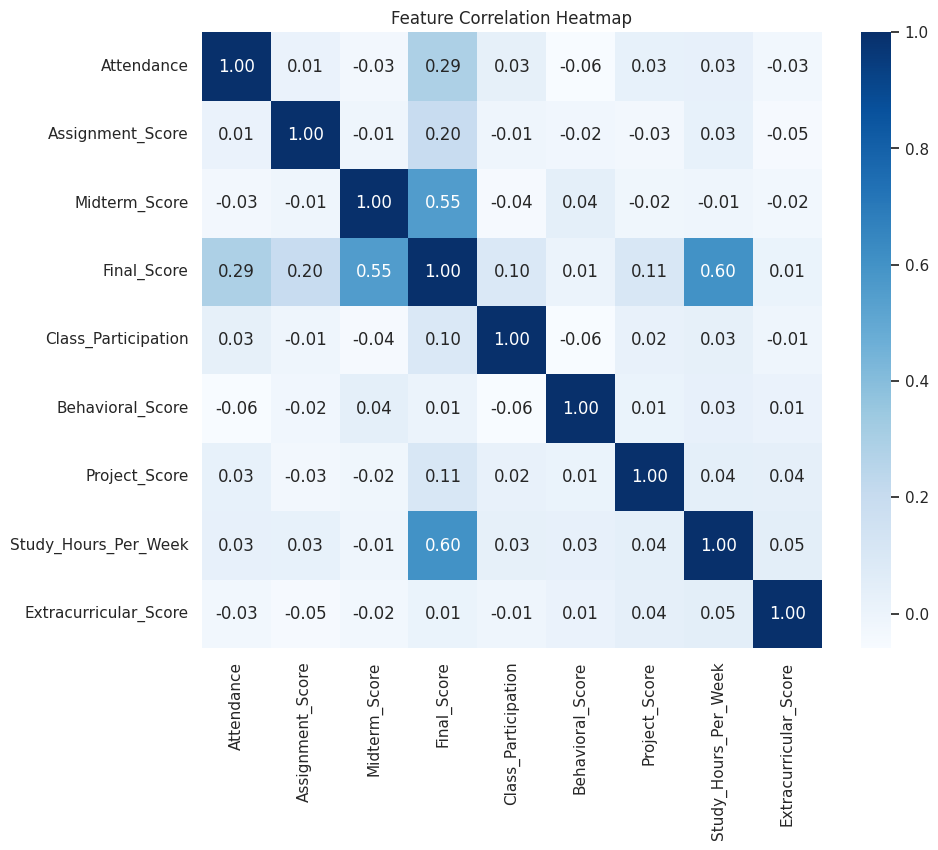

In [5]:
#Data visualization
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

#plot of Study_Hours_Per_Week vs Final_Score
plt.subplot(1, 2, 1)
plt.scatter(x="Study_Hours_Per_Week",y="Final_Score",data=df,color='royalblue', alpha=0.7)
plt.title("Study_Hours_Per_Week vs Final_Score")
plt.xlabel("Study_Hours_Per_Week(scaled)")
plt.ylabel("Final_Score(scaled)")

#Scatter plot of Attendance vs Final Score
plt.subplot(1,2,2)
plt.scatter(x="Attendance",y="Final_Score", data=df, color='seagreen', alpha=0.7)
plt.title("Attendance vs Final_Score")
plt.xlabel("Attendance(scaled)")
plt.ylabel("Final_Score(scaled)")

plt.tight_layout()
plt.show()

#correlation Heatmap
plt.figure(figsize=(10,8))

#correlation matrix
correlation_matrix = df.corr()

#draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()



#Select Features and Target :

In [6]:
# We drop the answer key (Final_Score) and the useless features we found in our heatmap
X = df.drop(columns=['Final_Score', 'Behavioral_Score', 'Extracurricular_Score'], axis=1)

# Create y (Target Variable)
y= df['Final_Score']

In [7]:
#Verify the shapes and features
print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)
print("\nSelected Features for Training:")
print(X.columns.tolist())

Shape of X (Features): (1000, 6)
Shape of y (Target): (1000,)

Selected Features for Training:
['Attendance', 'Assignment_Score', 'Midterm_Score', 'Class_Participation', 'Project_Score', 'Study_Hours_Per_Week']


#Split the Dataset :

In [8]:
#import libraries and split dataset

from sklearn.model_selection import train_test_split

#spliting the dataset into 80, 20 raito
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to verify the split
print("Training Data Shape (X_train):", X_train.shape)
print("Testing Data Shape (X_test):", X_test.shape)
print("Training Target Shape (y_train):", y_train.shape)
print("Testing Target Shape (y_test):", y_test.shape)

Training Data Shape (X_train): (800, 6)
Testing Data Shape (X_test): (200, 6)
Training Target Shape (y_train): (800,)
Testing Target Shape (y_test): (200,)


#Feature Scaling :

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
#Initialize the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Before Scaling (First row of X_train) ---")
print(X_train.iloc[0].values)

print("\n--- After Scaling (First row of X_train_scaled) ---")
print(X_train_scaled[0])

--- Before Scaling (First row of X_train) ---
[0.42787025 0.75792222 0.74259751 0.4883796  0.46069937 0.84602393]

--- After Scaling (First row of X_train_scaled) ---
[-1.5340594   0.50747353  0.50844492 -0.44527338 -1.35366779  1.07782942]


# Building a Baseline Regression Model :

In [11]:
from sklearn.linear_model import LinearRegression
import pandas as pd

In [13]:
#Initialize the model
baseline_model = LinearRegression()

In [14]:
#train the Model
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [15]:
#make prediction
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [18]:
comparison_df = pd.DataFrame({
    'Actual_Final_Score': y_test[:5].values,
    'Model_Predicted_Score': y_pred_baseline[:5]
})

print("--- First 5 Predictions vs Actual Scores ---")
display(comparison_df)

--- First 5 Predictions vs Actual Scores ---


,Actual_Final_Score,Model_Predicted_Score
0,0.707592,0.682052
1,0.608873,0.639794
2,0.815805,0.791714
3,0.668397,0.644707
4,0.475870,0.455914


#Evaluate the Regression Model :

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [20]:
# Calculate metrics by comparing the actual test answers against the model's guesses
mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_baseline)

print("--- Linear Regression Performance ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²) Score:           {r2:.4f}")

--- Linear Regression Performance ---
Mean Absolute Error (MAE):      0.0440
Mean Squared Error (MSE):       0.0030
Root Mean Squared Error (RMSE): 0.0547
R-squared (R²) Score:           0.7834


#Train Additional Models :

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [22]:
#Initialize the new models

tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42)

In [23]:
#Train the models on the same scaled training data

tree_model.fit(X_train_scaled, y_train)
forest_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [24]:
#Making Predictions

y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_forest = forest_model.predict(X_test_scaled)

In [26]:
#Calculate their R² scores for a quick comparison
r2_tree = r2_score(y_test, y_pred_tree)
r2_forest = r2_score(y_test, y_pred_forest)

#Print the results
print("--- Model Comparison (R² Scores) ---")
print(f"Linear Regression R²: {r2:.4f}")
print(f"Decision Tree R²:     {r2_tree:.4f}")
print(f"Random Forest R²:     {r2_forest:.4f}")

--- Model Comparison (R² Scores) ---
Linear Regression R²: 0.7834
Decision Tree R²:     0.5255
Random Forest R²:     0.7289


#Compare the Models :

In [28]:
# Calculate the remaining metrics for our Tree and Forest models
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)\

#creating a comparision dictonary
comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, mae_tree, mae_forest],
    'MSE': [mse, mse_tree, mse_forest],
    'RMSE': [rmse, rmse_tree, rmse_forest],
    'R² Score': [r2, r2_tree, r2_forest]
}

In [29]:
# Convert the dictionary into a Pandas DataFrame for a beautiful table
comparison_df = pd.DataFrame(comparison_data)

# Print the final comparison table
print("--- Final Model Comparison ---")
display(comparison_df)

--- Final Model Comparison ---


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.043963,0.002990,0.054684,0.783437
1,Decision Tree,0.064052,0.006552,0.080942,0.525525
2,Random Forest,0.048535,0.003743,0.061181,0.728918


#Visualize Model Performance :

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

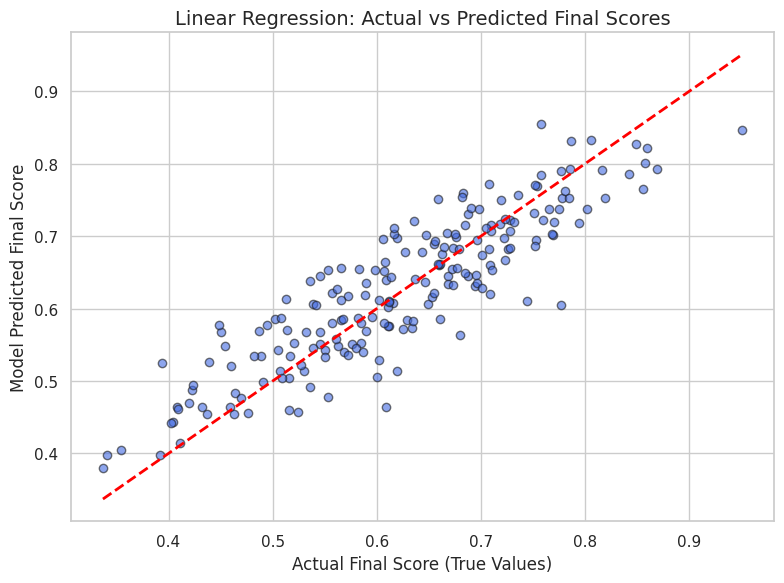

In [31]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Plot the Actual Scores (X-axis) against the Predicted Scores (Y-axis)
plt.scatter(y_test, y_pred_baseline, color='royalblue', alpha=0.6, edgecolor='k')

# Draw a perfect diagonal line
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Linear Regression: Actual vs Predicted Final Scores', fontsize=14)
plt.xlabel('Actual Final Score (True Values)', fontsize=12)
plt.ylabel('Model Predicted Final Score', fontsize=12)

plt.tight_layout()
plt.show()

#Finalizing  and Saving the Model :

In [32]:
import joblib

In [34]:
#Save the trained Linear Regression model
joblib.dump(baseline_model, 'student_performance_model.pkl')

#save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

#Save the exact list of feature names used for training
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']